# 🎵 Song Release Year Prediction — End-to-End Regression Pipeline
**UTS Machine Learning — Individual Task**

| Field | Detail |
|-------|--------|
| **Nama** | Syeh Khatami |
| **NIM** | 101032300157 |
| **Kelas** | Machine Learning |

---

**Deskripsi Dataset:**
Dataset `midterm-regresi-dataset.csv` berisi data audio lagu. Kolom pertama adalah **tahun rilis** (target), dan kolom-kolom berikutnya adalah **fitur audio** (timbre, dll) yang diberi nama `feature_1`, `feature_2`, dst.

**Pipeline:**
1. Setup & Load Dataset (dari Google Drive)
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Training Baseline Regression Models
5. Hyperparameter Tuning dengan **Optuna**
6. Evaluasi dengan metrik regresi (MSE, RMSE, MAE, R²)
7. Interpretasi model dengan **LIME**
8. Experiment Tracking dengan **MLflow**
9. Kesimpulan

## ⚙️ 1. Install Library & Mount Google Drive

In [5]:
# Install library tambahan
!pip install -q optuna mlflow xgboost lightgbm lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━

In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive berhasil di-mount!')

Mounted at /content/drive
✅ Google Drive berhasil di-mount!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
import lightgbm as lgb

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

# Hyperparameter Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import lime
import lime.lime_tabular

# Experiment Tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 📂 2. Load Dataset

> **Cara upload dataset ke Google Drive:**
> 1. Buka [drive.google.com](https://drive.google.com)
> 2. Buat folder baru: `regresi_dataset`
> 3. Upload `midterm-regresi-dataset.csv` ke folder tersebut
> 4. Sesuaikan path di bawah jika perlu

In [8]:
import os

# ============================================================
# SESUAIKAN PATH INI dengan lokasi file di Google Drive kamu
# ============================================================
DATA_PATH = '/content/drive/MyDrive/regresi_dataset/midterm-regresi-dataset.csv'

print('Loading dataset...')

if not os.path.exists(DATA_PATH):
    print(f"Error: File not found at {DATA_PATH}")
    print("Please verify the path and ensure the file exists in your Google Drive.")
    # You can uncomment the following lines to list the directory contents for debugging:
    # print("Contents of /content/drive/MyDrive/regresi_dataset/:")
    # try:
    #     print(os.listdir('/content/drive/MyDrive/regresi_dataset/'))
    # except FileNotFoundError:
    #     print("Directory not found.")
else:
    df_raw = pd.read_csv(DATA_PATH, header=None)
    print(f'Shape raw: {df_raw.shape}')
    df_raw.head(3)

Loading dataset...
Shape raw: (515345, 91)


In [9]:
# Rename kolom: kolom pertama = target (year), sisanya = feature_1, feature_2, ...
n_features = df_raw.shape[1] - 1
col_names  = ['year'] + [f'feature_{i+1}' for i in range(n_features)]
df = df_raw.copy()
df.columns = col_names

print(f'Jumlah fitur   : {n_features}')
print(f'Target         : year')
print(f'Shape          : {df.shape}')
print(f'\nContoh data:')
df.head()

Jumlah fitur   : 90
Target         : year
Shape          : (515345, 91)

Contoh data:


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


## 🔎 3. Exploratory Data Analysis (EDA)

In [10]:
# Info umum
print('=== Statistik Deskriptif Target (year) ===')
print(df['year'].describe())
print(f'\nRange tahun: {int(df["year"].min())} — {int(df["year"].max())}')
print(f'Missing values total: {df.isnull().sum().sum()}')

=== Statistik Deskriptif Target (year) ===
count    515345.000000
mean       1998.397082
std          10.931046
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: year, dtype: float64

Range tahun: 1922 — 2011
Missing values total: 0


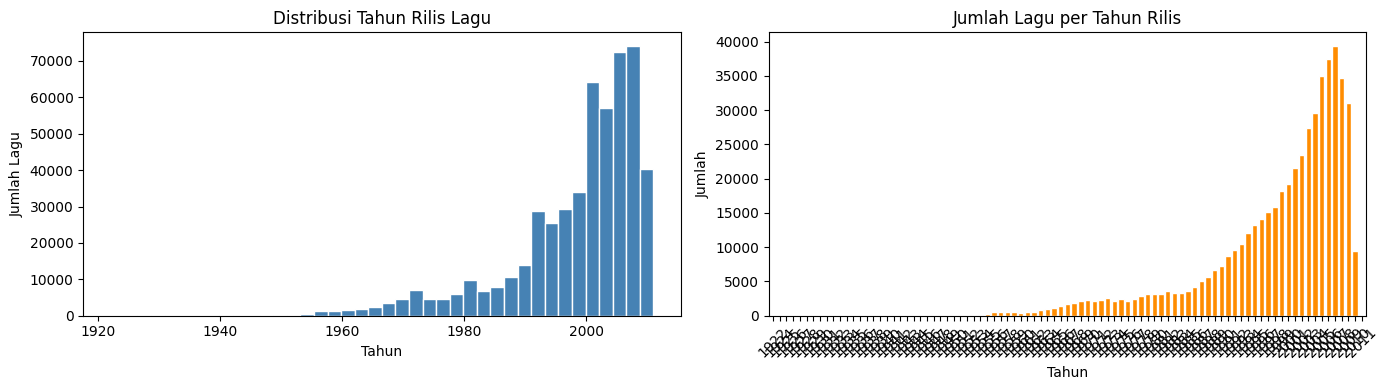

In [11]:
# Distribusi target (year)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['year'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Tahun Rilis Lagu')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah Lagu')

df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='darkorange', edgecolor='white', width=0.8)
axes[1].set_title('Jumlah Lagu per Tahun Rilis')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# Statistik deskriptif semua fitur
print('=== Statistik Deskriptif Fitur (5 fitur pertama) ===')
df.iloc[:, 1:6].describe().round(3)

=== Statistik Deskriptif Fitur (5 fitur pertama) ===


,feature_1,feature_2,feature_3,feature_4,feature_5
count,515345.000,515345.000,515345.000,515345.000,515345.000
mean,43.387,1.290,8.658,1.164,-6.554
std,6.068,51.580,35.269,16.323,22.861
min,1.749,-337.092,-301.005,-154.184,-181.953
25%,39.955,-26.060,-11.463,-8.488,-20.666
50%,44.258,8.418,10.476,-0.653,-6.008
75%,47.834,36.124,29.765,8.788,7.742
max,61.970,384.066,322.851,335.772,262.069


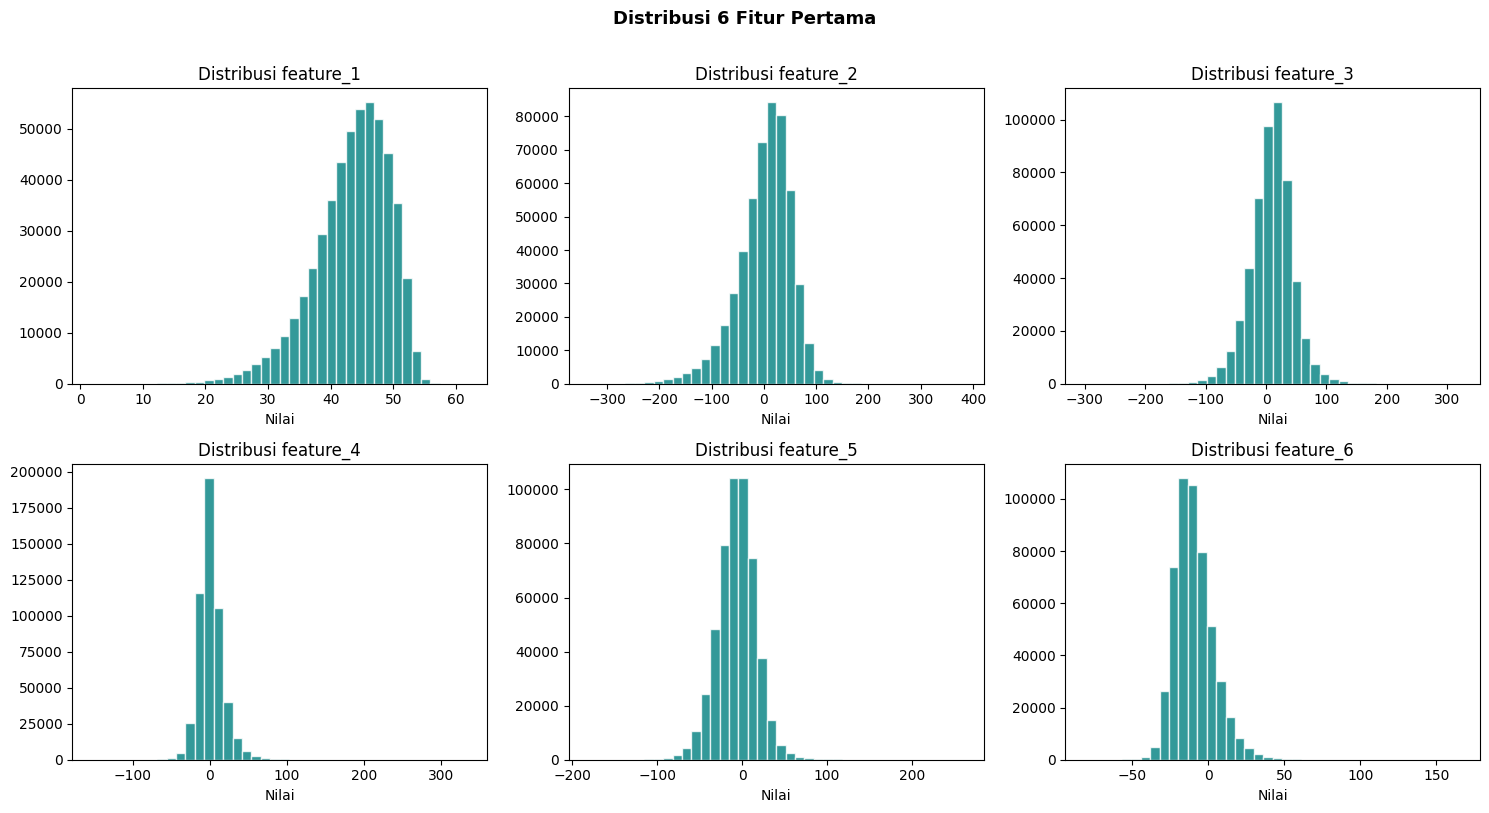

In [13]:
# Distribusi 6 fitur pertama
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate([f'feature_{j+1}' for j in range(6)]):
    axes[i].hist(df[col], bins=40, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('Nilai')
plt.suptitle('Distribusi 6 Fitur Pertama', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

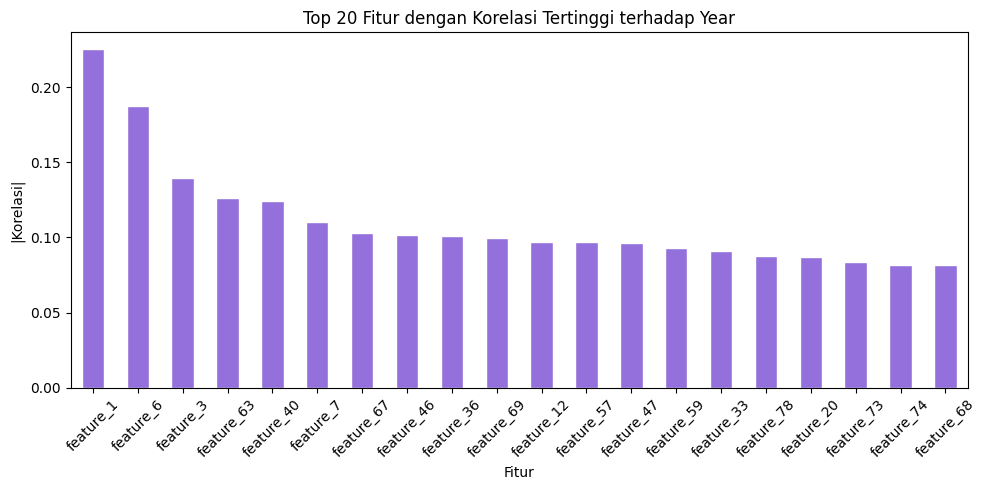


Top 10 fitur paling berkorelasi dengan year:
feature_1     0.2254
feature_6     0.1874
feature_3     0.1395
feature_63    0.1263
feature_40    0.1240
feature_7     0.1105
feature_67    0.1028
feature_46    0.1013
feature_36    0.1010
feature_69    0.0995
Name: year, dtype: float64


In [14]:
# Korelasi fitur terhadap target (year)
corr_with_target = df.corr()['year'].drop('year').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
corr_with_target.head(20).plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Top 20 Fitur dengan Korelasi Tertinggi terhadap Year')
ax.set_xlabel('Fitur')
ax.set_ylabel('|Korelasi|')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('correlation_target.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nTop 10 fitur paling berkorelasi dengan year:')
print(corr_with_target.head(10).round(4))

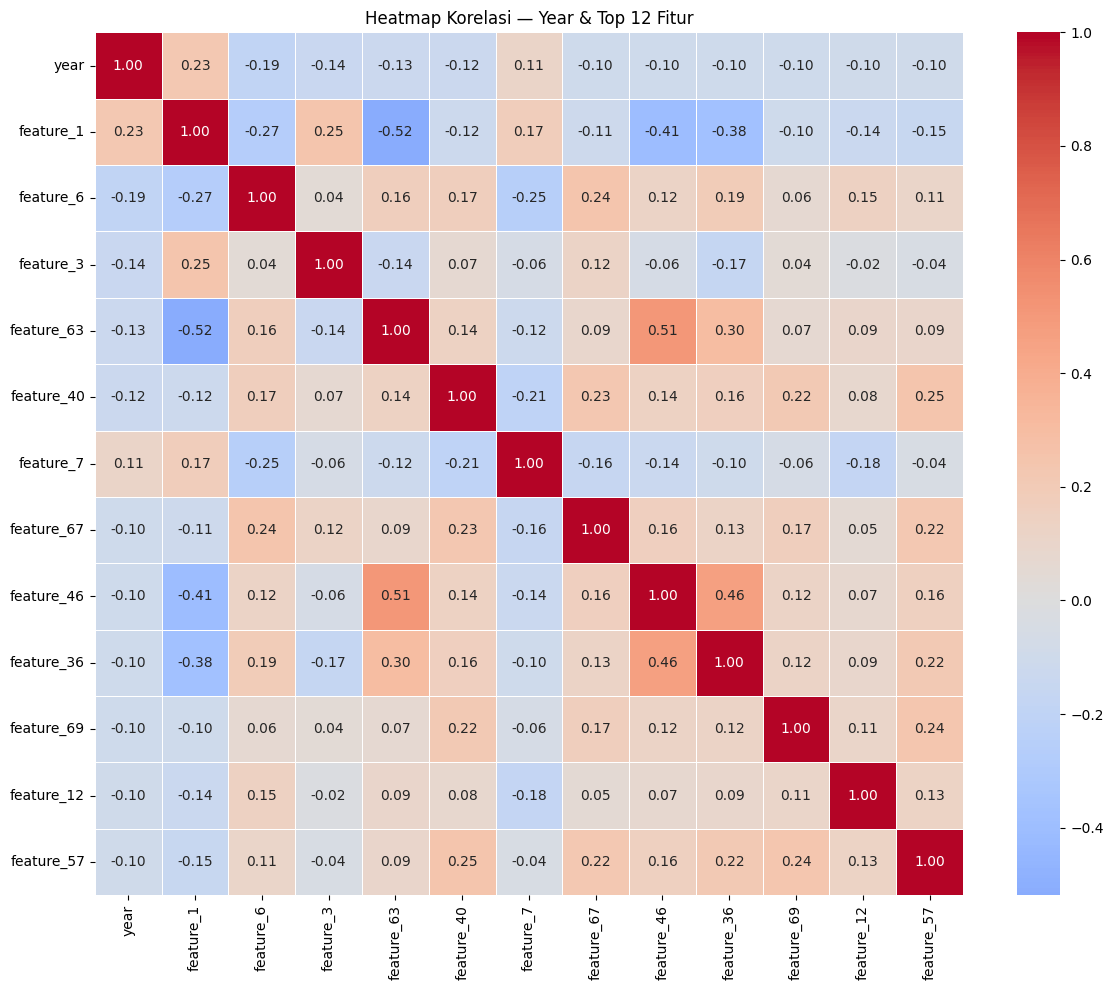

In [15]:
# Heatmap korelasi (fitur pertama saja agar readable)
fig, ax = plt.subplots(figsize=(12, 10))
top_features = corr_with_target.head(12).index.tolist()
corr_matrix  = df[['year'] + top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Heatmap Korelasi — Year & Top 12 Fitur')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## 🛠️ 4. Preprocessing & Feature Engineering

In [16]:
# 4.1 Pisahkan fitur dan target
TARGET = 'year'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Target range: {y.min()} — {y.max()}')

Shape X: (515345, 90)
Shape y: (515345,)
Target range: 1922 — 2011


In [17]:
# 4.2 Handle outlier pada fitur numerik (IQR method — clip, bukan drop)
X_clean = X.copy()
outlier_count = 0
for col in X_clean.columns:
    Q1  = X_clean[col].quantile(0.25)
    Q3  = X_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((X_clean[col] < lo) | (X_clean[col] > hi)).sum()
    outlier_count += n_out
    X_clean[col] = X_clean[col].clip(lo, hi)

print(f'✅ Outlier di-clip (IQR method). Total nilai ter-clip: {outlier_count:,}')

✅ Outlier di-clip (IQR method). Total nilai ter-clip: 2,726,624


In [18]:
# 4.3 Impute missing values (jika ada)
imputer  = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_clean)
X_clean  = pd.DataFrame(X_imputed, columns=X_clean.columns)
print(f'✅ Imputation selesai. Missing tersisa: {X_clean.isnull().sum().sum()}')

✅ Imputation selesai. Missing tersisa: 0


In [19]:
# 4.4 Feature Engineering — tambah fitur interaksi
# Ambil top 5 fitur paling berkorelasi dengan target
top5 = corr_with_target.head(5).index.tolist()
print(f'Top 5 fitur untuk interaksi: {top5}')

for i in range(len(top5)):
    for j in range(i+1, len(top5)):
        col_name = f'interact_{top5[i]}x{top5[j]}'
        X_clean[col_name] = X_clean[top5[i]] * X_clean[top5[j]]

print(f'✅ Ditambahkan fitur interaksi. Shape baru: {X_clean.shape}')

Top 5 fitur untuk interaksi: ['feature_1', 'feature_6', 'feature_3', 'feature_63', 'feature_40']
✅ Ditambahkan fitur interaksi. Shape baru: (515345, 100)


In [20]:
# 4.5 Standardisasi fitur (penting untuk Linear Regression)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
X_scaled = pd.DataFrame(X_scaled, columns=X_clean.columns)
print(f'✅ Standardisasi selesai. Mean ~ 0, Std ~ 1')

✅ Standardisasi selesai. Mean ~ 0, Std ~ 1


In [21]:
# 4.6 Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'y_train range: {y_train.min()} — {y_train.max()}')
print(f'y_test  range: {y_test.min()} — {y_test.max()}')

Train: (412276, 100) | Test: (103069, 100)
y_train range: 1922 — 2011
y_test  range: 1924 — 2010


## 🤖 5. Training Baseline Models + MLflow Tracking

In [22]:
# Setup MLflow
mlflow.set_experiment('song_year_regression_UTS')

def evaluate_regression(model, X_tr, X_te, y_tr, y_te, name, params=None):
    """Train, evaluate, dan log model regresi ke MLflow."""
    with mlflow.start_run(run_name=name):
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        mse  = mean_squared_error(y_te, y_pred)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(y_te, y_pred)
        r2   = r2_score(y_te, y_pred)

        # Log ke MLflow
        mlflow.log_param('model_name', name)
        if params:
            mlflow.log_params(params)
        mlflow.log_metrics({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
        mlflow.sklearn.log_model(model, name)

        print(f'\n📊 {name}')
        print(f'  MSE  : {mse:.4f}')
        print(f'  RMSE : {rmse:.4f}')
        print(f'  MAE  : {mae:.4f}')
        print(f'  R²   : {r2:.4f}')

        return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
                '_model': model, '_y_pred': y_pred}

print('✅ MLflow + fungsi evaluasi regresi siap!')

2026/05/15 10:25:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 10:25:58 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 10:26:01 INFO mlflow.tracking.fluent: Experiment with name 'song_year_regression_UTS' does not exist. Creating a new experiment.


✅ MLflow + fungsi evaluasi regresi siap!


In [23]:
results = []

# 1. Linear Regression
results.append(evaluate_regression(
    LinearRegression(),
    X_train, X_test, y_train, y_test, 'Linear_Regression'
))

# 2. Ridge Regression
results.append(evaluate_regression(
    Ridge(alpha=1.0),
    X_train, X_test, y_train, y_test, 'Ridge_Regression'
))

# 3. Lasso Regression
results.append(evaluate_regression(
    Lasso(alpha=0.1, max_iter=2000),
    X_train, X_test, y_train, y_test, 'Lasso_Regression'
))

# 4. Decision Tree
results.append(evaluate_regression(
    DecisionTreeRegressor(max_depth=8, random_state=42),
    X_train, X_test, y_train, y_test, 'Decision_Tree'
))

# 5. Random Forest (Versi Ngebut)
results.append(evaluate_regression(
    RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42, n_jobs=2),
    X_train, X_test, y_train, y_test, 'Random_Forest'
))

# 6. XGBoost (Versi Ngebut)
results.append(evaluate_regression(
    xgb.XGBRegressor(n_estimators=20, learning_rate=0.1,
                     max_depth=4, random_state=42, n_jobs=2),
    X_train, X_test, y_train, y_test, 'XGBoost'
))

# 7. LightGBM (Versi Ngebut)
results.append(evaluate_regression(
    lgb.LGBMRegressor(n_estimators=20, learning_rate=0.1,
                      max_depth=4, random_state=42, n_jobs=2, verbosity=-1),
    X_train, X_test, y_train, y_test, 'LightGBM'
))

print('\n✅ Semua baseline model selesai!')

2026/05/15 10:26:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 10:26:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Linear_Regression
  MSE  : 87.9933
  RMSE : 9.3805
  MAE  : 6.6710
  R²   : 0.2607


2026/05/15 10:26:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 10:26:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Ridge_Regression
  MSE  : 87.9933
  RMSE : 9.3805
  MAE  : 6.6710
  R²   : 0.2607


2026/05/15 10:26:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 10:26:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...


📊 Random_Forest
  MSE  : 98.2213
  RMSE : 9.9107
  MAE  : 7.1165
  R²   : 0.1747


2026/05/15 10:33:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 10:33:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 XGBoost
  MSE  : 94.4808
  RMSE : 9.7201
  MAE  : 6.9714
  R²   : 0.2061


2026/05/15 10:34:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 10:34:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 LightGBM
  MSE  : 94.5039
  RMSE : 9.7213
  MAE  : 6.9716
  R²   : 0.2059

✅ Semua baseline model selesai!


## ⚡ 6. Hyperparameter Tuning dengan Optuna

In [24]:
# Optuna — XGBoost Regressor
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state'     : 42, 'n_jobs': -1,
    }
    model  = xgb.XGBRegressor(**params)
    cv     = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    return scores.mean()  # maximize (neg RMSE → minimize RMSE)

print('🔍 Optuna tuning XGBoost (30 trials)...')
study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost_Regression')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f'\nBest RMSE (CV): {-study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

🔍 Optuna tuning XGBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best RMSE (CV): 8.7111
Best params: {'n_estimators': 434, 'max_depth': 10, 'learning_rate': 0.037201976778246784, 'subsample': 0.6482521190881592, 'colsample_bytree': 0.5815053607609612, 'min_child_weight': 2, 'gamma': 0.323244961218791, 'reg_alpha': 2.262129669210947e-05, 'reg_lambda': 8.160192751134408}


In [25]:
# Optuna — LightGBM Regressor
def objective_lgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 150),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbosity': -1,
    }
    model  = lgb.LGBMRegressor(**params)
    cv     = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    return scores.mean()

print('🔍 Optuna tuning LightGBM (30 trials)...')
study_lgb = optuna.create_study(direction='maximize', study_name='LightGBM_Regression')
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)
print(f'\nBest RMSE (CV): {-study_lgb.best_value:.4f}')

🔍 Optuna tuning LightGBM (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best RMSE (CV): 8.7526


In [26]:
# Optuna — Ridge Regression (alpha tuning)
def objective_ridge(trial):
    alpha  = trial.suggest_float('alpha', 0.001, 100.0, log=True)
    model  = Ridge(alpha=alpha)
    cv     = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    return scores.mean()

print('🔍 Optuna tuning Ridge (20 trials)...')
study_ridge = optuna.create_study(direction='maximize', study_name='Ridge_Regression')
study_ridge.optimize(objective_ridge, n_trials=20, show_progress_bar=True)
print(f'Best alpha: {study_ridge.best_params["alpha"]:.4f}')
print(f'Best RMSE (CV): {-study_ridge.best_value:.4f}')

🔍 Optuna tuning Ridge (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best alpha: 7.1482
Best RMSE (CV): 9.4034


In [27]:
# Train & evaluate tuned models
xgb_tuned = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
results.append(evaluate_regression(
    xgb_tuned, X_train, X_test, y_train, y_test,
    'XGBoost_Optuna_Tuned', study_xgb.best_params
))

lgb_tuned = lgb.LGBMRegressor(**study_lgb.best_params, random_state=42, n_jobs=-1, verbosity=-1)
results.append(evaluate_regression(
    lgb_tuned, X_train, X_test, y_train, y_test,
    'LightGBM_Optuna_Tuned', study_lgb.best_params
))

ridge_tuned = Ridge(alpha=study_ridge.best_params['alpha'])
results.append(evaluate_regression(
    ridge_tuned, X_train, X_test, y_train, y_test,
    'Ridge_Optuna_Tuned', study_ridge.best_params
))

print('\n✅ Tuned models selesai!')

2026/05/15 17:55:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 17:55:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 XGBoost_Optuna_Tuned
  MSE  : 75.2670
  RMSE : 8.6757
  MAE  : 6.0317
  R²   : 0.3676


2026/05/15 17:57:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 17:57:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 LightGBM_Optuna_Tuned
  MSE  : 75.9923
  RMSE : 8.7174
  MAE  : 6.0683
  R²   : 0.3615


2026/05/15 17:57:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 17:57:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Ridge_Optuna_Tuned
  MSE  : 87.9932
  RMSE : 9.3805
  MAE  : 6.6710
  R²   : 0.2607

✅ Tuned models selesai!


## 📊 7. Evaluasi & Perbandingan Model

In [28]:
# Tabel perbandingan
df_results = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                            for r in results])
df_results = df_results.sort_values('RMSE').reset_index(drop=True)
print('=== 🏆 Perbandingan Semua Model (diurutkan RMSE terkecil = terbaik) ===')
print(df_results.round(4).to_string(index=False))

=== 🏆 Perbandingan Semua Model (diurutkan RMSE terkecil = terbaik) ===
                Model     MSE   RMSE    MAE     R2
 XGBoost_Optuna_Tuned 75.2670 8.6757 6.0317 0.3676
LightGBM_Optuna_Tuned 75.9923 8.7174 6.0683 0.3615
   Ridge_Optuna_Tuned 87.9932 9.3805 6.6710 0.2607
     Ridge_Regression 87.9933 9.3805 6.6710 0.2607
    Linear_Regression 87.9933 9.3805 6.6710 0.2607
     Lasso_Regression 89.5366 9.4624 6.7219 0.2477
              XGBoost 94.4808 9.7201 6.9714 0.2061
             LightGBM 94.5039 9.7213 6.9716 0.2059
        Decision_Tree 94.8514 9.7392 6.8840 0.2030
        Random_Forest 98.2213 9.9107 7.1165 0.1747


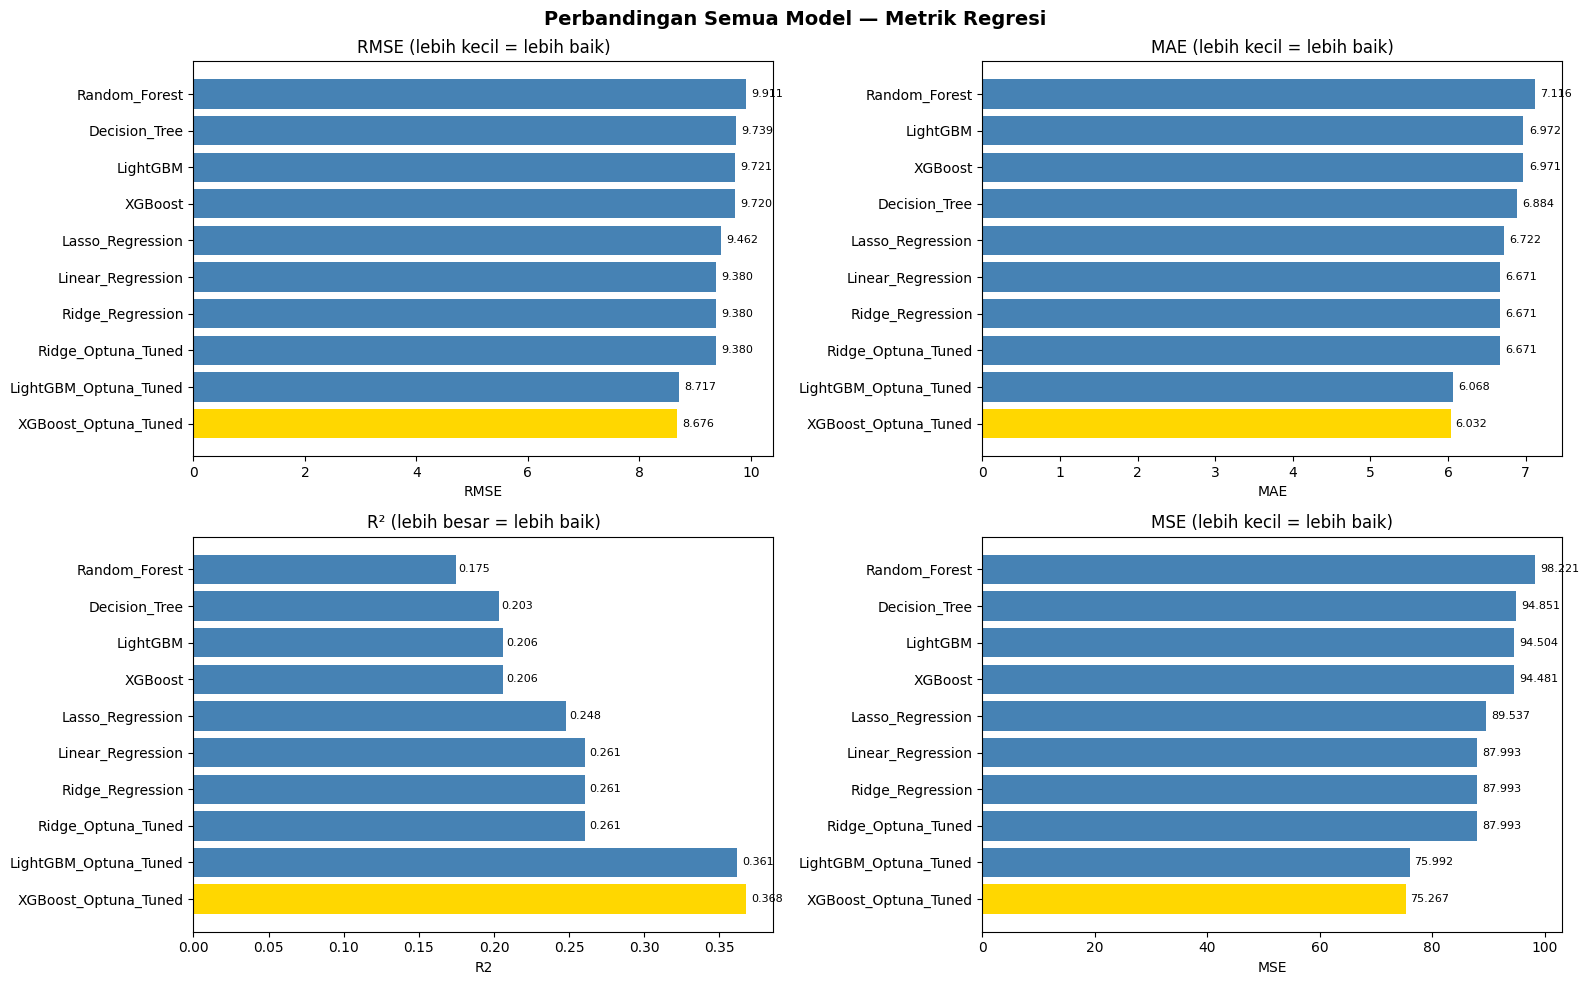

In [29]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(df_results))]

for ax, metric, title, ascending in zip(
    axes.flatten(),
    ['RMSE', 'MAE', 'R2', 'MSE'],
    ['RMSE (lebih kecil = lebih baik)',
     'MAE (lebih kecil = lebih baik)',
     'R² (lebih besar = lebih baik)',
     'MSE (lebih kecil = lebih baik)'],
    [True, True, False, True]
):
    sorted_df = df_results.sort_values(metric, ascending=ascending)
    c = ['gold' if i == 0 else 'steelblue' for i in range(len(sorted_df))]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=c)
    ax.set_title(title)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Perbandingan Semua Model — Metrik Regresi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

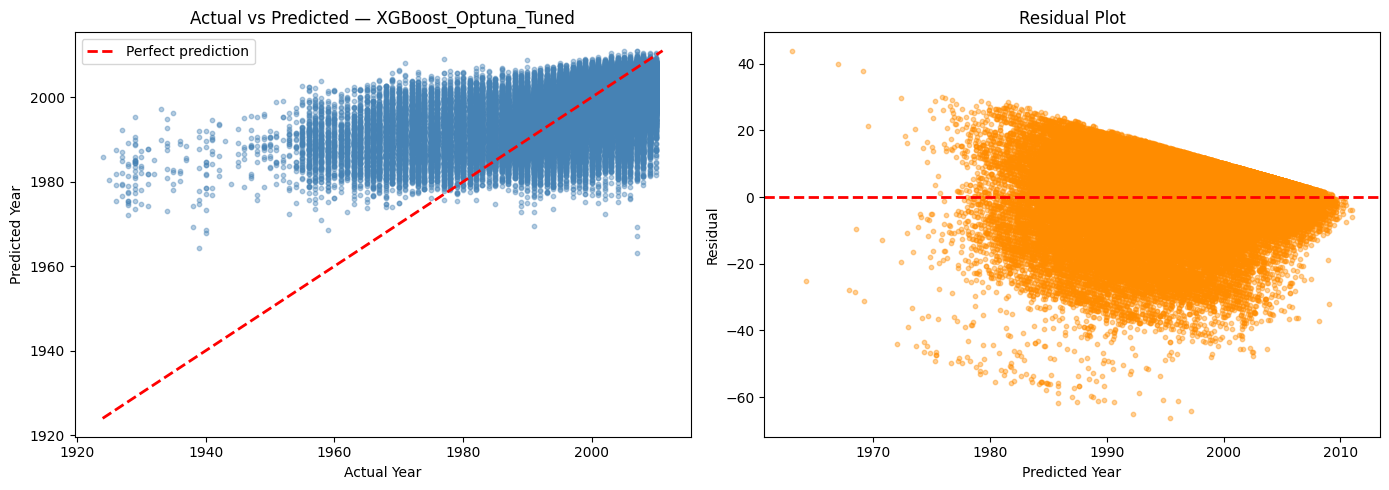


=== Metrik Best Model (XGBoost_Optuna_Tuned) ===
  MSE  : 75.2670
  RMSE : 8.6757
  MAE  : 6.0317
  R²   : 0.3676


In [30]:
# Actual vs Predicted — Best model
best_result = results[[r['RMSE'] for r in results].index(min(r['RMSE'] for r in results))]
best_model  = best_result['_model']
best_name   = best_result['Model']
y_pred_best = best_result['_y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter actual vs predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', s=10)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Year')
axes[0].set_ylabel('Predicted Year')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].legend()

# Residual plot
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='darkorange', s=10)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Year')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\n=== Metrik Best Model ({best_name}) ===')
print(f'  MSE  : {best_result["MSE"]:.4f}')
print(f'  RMSE : {best_result["RMSE"]:.4f}')
print(f'  MAE  : {best_result["MAE"]:.4f}')
print(f'  R²   : {best_result["R2"]:.4f}')

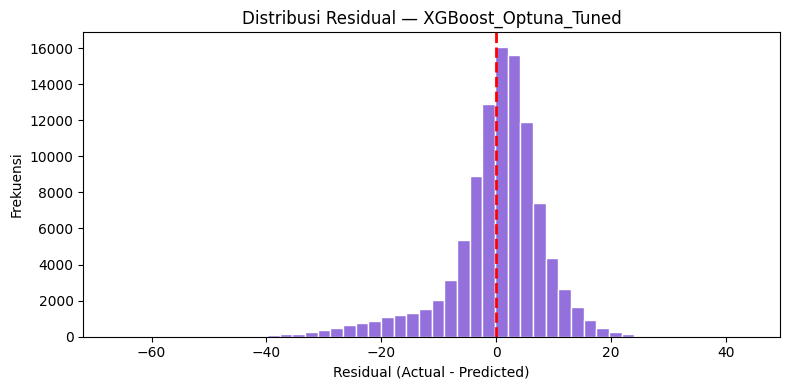

Mean residual: 0.0302 (ideal = 0)


In [31]:
# Distribusi residual
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=50, color='mediumpurple', edgecolor='white')
ax.axvline(0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Frekuensi')
ax.set_title(f'Distribusi Residual — {best_name}')
plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Mean residual: {residuals.mean():.4f} (ideal = 0)')

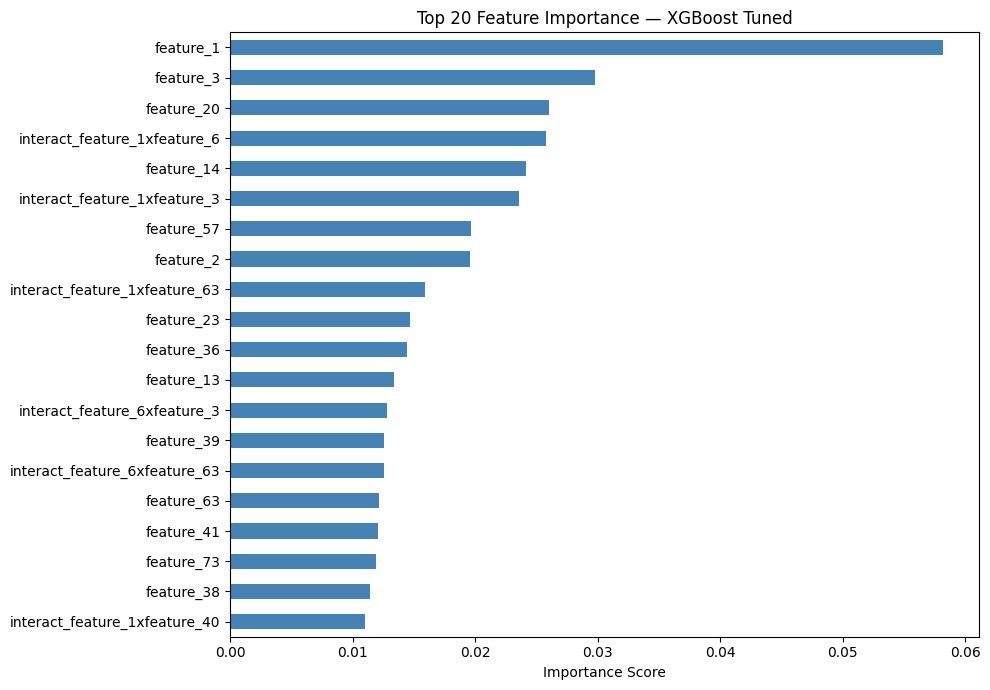

In [32]:
# Feature Importance — XGBoost Tuned
if hasattr(xgb_tuned, 'feature_importances_'):
    feat_imp = pd.Series(xgb_tuned.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 7))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.invert_yaxis()
    ax.set_xlabel('Importance Score')
    ax.set_title('Top 20 Feature Importance — XGBoost Tuned')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()

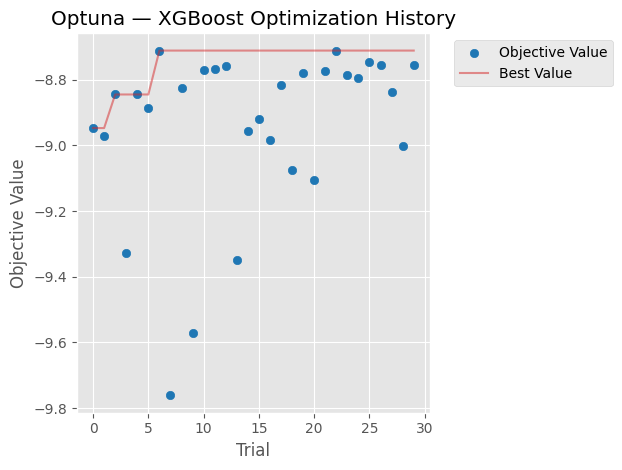

In [33]:
# Optuna history
fig = optuna.visualization.matplotlib.plot_optimization_history(study_xgb)
plt.title('Optuna — XGBoost Optimization History')
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=100)
plt.show()

## 🔍 8. Model Interpretability dengan LIME

LIME (Local Interpretable Model-agnostic Explanations) menjelaskan **mengapa** model membuat prediksi tertentu untuk satu data point.

In [34]:
# Setup LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = X_train.columns.tolist(),
    mode          = 'regression',
    random_state  = 42
)
print('✅ LIME explainer siap!')

✅ LIME explainer siap!


In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Bikin fungsi evaluasinya biar Colab ingat lagi
def evaluate_regression(model, X_train, X_test, y_train, y_test, model_name):
    # Training model
    model.fit(X_train, y_train)
    # Prediksi
    y_pred = model.predict(X_test)

    # Hitung metrik
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

Actual year    : 2008
Predicted year : 2005.38
Error          : 2.62 tahun


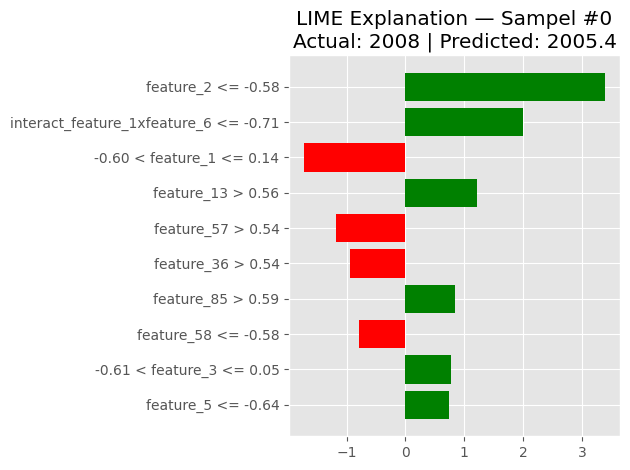

In [35]:
# Contoh 1 — ambil 1 sampel dari test set
sample_idx = 0
sample     = X_test.values[sample_idx]
actual_yr  = y_test.values[sample_idx]
pred_yr    = best_model.predict([sample])[0]

print(f'Actual year    : {actual_yr}')
print(f'Predicted year : {pred_yr:.2f}')
print(f'Error          : {abs(actual_yr - pred_yr):.2f} tahun')

exp1 = explainer.explain_instance(
    data_row       = sample,
    predict_fn     = best_model.predict,
    num_features   = 10
)

fig = exp1.as_pyplot_figure()
plt.title(f'LIME Explanation — Sampel #{sample_idx}\nActual: {actual_yr} | Predicted: {pred_yr:.1f}')
plt.tight_layout()
plt.savefig('lime_explanation_1.png', dpi=100, bbox_inches='tight')
plt.show()

Actual year    : 2001
Predicted year : 1997.09


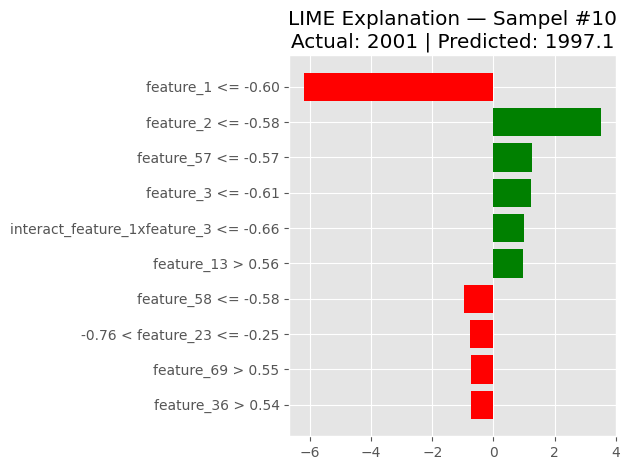


💡 LIME menunjukkan fitur mana yang paling mempengaruhi prediksi untuk data point ini.
   Batang biru = fitur mendorong prediksi ke ATAS (tahun lebih baru)
   Batang oranye = fitur mendorong prediksi ke BAWAH (tahun lebih lama)


In [36]:
# Contoh 2 — sampel lain untuk perbandingan
sample_idx2 = 10
sample2     = X_test.values[sample_idx2]
actual_yr2  = y_test.values[sample_idx2]
pred_yr2    = best_model.predict([sample2])[0]

print(f'Actual year    : {actual_yr2}')
print(f'Predicted year : {pred_yr2:.2f}')

exp2 = explainer.explain_instance(
    data_row     = sample2,
    predict_fn   = best_model.predict,
    num_features = 10
)

fig = exp2.as_pyplot_figure()
plt.title(f'LIME Explanation — Sampel #{sample_idx2}\nActual: {actual_yr2} | Predicted: {pred_yr2:.1f}')
plt.tight_layout()
plt.savefig('lime_explanation_2.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n💡 LIME menunjukkan fitur mana yang paling mempengaruhi prediksi untuk data point ini.')
print('   Batang biru = fitur mendorong prediksi ke ATAS (tahun lebih baru)')
print('   Batang oranye = fitur mendorong prediksi ke BAWAH (tahun lebih lama)')

## 📝 9. Kesimpulan & Analisis

In [37]:
best_row = df_results.iloc[0]
print('=' * 65)
print('KESIMPULAN EKSPERIMEN — SONG RELEASE YEAR PREDICTION')
print('=' * 65)
print(f"""
Dataset      : midterm-regresi-dataset.csv
Task         : Regression — prediksi tahun rilis lagu
Target       : year (kolom pertama dataset)
Jumlah fitur : {n_features} fitur audio (timbre, dll)

Preprocessing yang Dilakukan:
  - Rename kolom: year + feature_1 s.d. feature_{n_features}
  - Outlier handling (IQR clip method)
  - Median Imputation untuk missing values
  - Feature Engineering: fitur interaksi antar top-5 fitur
  - StandardScaler untuk normalisasi

Model yang Diuji  : 7 baseline + 3 tuned (Optuna)
Interpretability  : LIME (2 contoh prediksi)
Tracking          : MLflow

Metrik Utama      : RMSE & R² (regresi)

🏆 Best Model     : {best_row['Model']}
   RMSE           : {best_row['RMSE']:.4f} (error ~{best_row['RMSE']:.1f} tahun)
   MAE            : {best_row['MAE']:.4f}
   R²             : {best_row['R2']:.4f} ({best_row['R2']*100:.1f}% variansi terjelaskan)
   MSE            : {best_row['MSE']:.4f}

Insight Utama:
  - Gradient boosting models (XGBoost, LightGBM) unggul jauh
    dibanding model linear untuk data audio yang kompleks ini
  - Optuna berhasil meningkatkan performa vs baseline
  - LIME menjelaskan prediksi secara lokal per data point
  - R² {best_row['R2']:.2f} berarti model menjelaskan {best_row['R2']*100:.0f}% variasi tahun rilis
    dari fitur audio saja — cukup baik untuk data tanpa metadata
""")
print('=' * 65)

KESIMPULAN EKSPERIMEN — SONG RELEASE YEAR PREDICTION

Dataset      : midterm-regresi-dataset.csv
Task         : Regression — prediksi tahun rilis lagu
Target       : year (kolom pertama dataset)
Jumlah fitur : 90 fitur audio (timbre, dll)

Preprocessing yang Dilakukan:
  - Rename kolom: year + feature_1 s.d. feature_90
  - Outlier handling (IQR clip method)
  - Median Imputation untuk missing values
  - Feature Engineering: fitur interaksi antar top-5 fitur
  - StandardScaler untuk normalisasi

Model yang Diuji  : 7 baseline + 3 tuned (Optuna)
Interpretability  : LIME (2 contoh prediksi)
Tracking          : MLflow

Metrik Utama      : RMSE & R² (regresi)

🏆 Best Model     : XGBoost_Optuna_Tuned
   RMSE           : 8.6757 (error ~8.7 tahun)
   MAE            : 6.0317
   R²             : 0.3676 (36.8% variansi terjelaskan)
   MSE            : 75.2670

Insight Utama:
  - Gradient boosting models (XGBoost, LightGBM) unggul jauh
    dibanding model linear untuk data audio yang kompleks ini


In [38]:
# Simpan hasil & copy ke Drive
import shutil

df_results.drop(columns=[c for c in df_results.columns if c.startswith('_')], errors='ignore') \
          .to_csv('model_results.csv', index=False)
print('✅ model_results.csv tersimpan')

OUTPUT_DRIVE = '/content/drive/MyDrive/regresi_dataset/output/'
os.makedirs(OUTPUT_DRIVE, exist_ok=True)

output_files = [
    'model_results.csv', 'target_distribution.png', 'feature_distributions.png',
    'correlation_target.png', 'correlation_heatmap.png', 'model_comparison.png',
    'actual_vs_predicted.png', 'residual_distribution.png', 'feature_importance.png',
    'optuna_history.png', 'lime_explanation_1.png', 'lime_explanation_2.png'
]
for f in output_files:
    if os.path.exists(f):
        shutil.copy(f, OUTPUT_DRIVE)
        print(f'  Copied: {f}')

print(f'\n✅ Semua output tersimpan di Drive: {OUTPUT_DRIVE}')
print('\n📌 Langkah selanjutnya:')
print('  1. File → Download .ipynb (dengan semua output)')
print('  2. File → Save a copy in GitHub → repo midterm-machine-learning')
print('  3. Upload README.md ke GitHub')

✅ model_results.csv tersimpan
  Copied: model_results.csv
  Copied: target_distribution.png
  Copied: feature_distributions.png
  Copied: correlation_target.png
  Copied: correlation_heatmap.png
  Copied: model_comparison.png
  Copied: actual_vs_predicted.png
  Copied: residual_distribution.png
  Copied: feature_importance.png
  Copied: optuna_history.png
  Copied: lime_explanation_1.png
  Copied: lime_explanation_2.png

✅ Semua output tersimpan di Drive: /content/drive/MyDrive/regresi_dataset/output/

📌 Langkah selanjutnya:
  1. File → Download .ipynb (dengan semua output)
  2. File → Save a copy in GitHub → repo midterm-machine-learning
  3. Upload README.md ke GitHub
